<div style="display: flex; background-color: #082858; border: 5px solid #17084f;">
<h1 style="margin: auto; padding: 30px; color: #ffffff;"> Détection de faux billets.💴💵💷💶</h1>
</div>

<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Chargement et description des données 📊</h3>
</div>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score

RANDOM_STATE = 42

billets = pd.read_csv("billets.csv", sep=";")

print(f"Dimensions : {billets.shape[0]} lignes, {billets.shape[1]} colonnes")
print(f"\nDoublons : {billets.duplicated().sum()}")
print(f"\nTypes :\n{billets.dtypes}")
print(f"\nValeurs manquantes :\n{billets.isna().sum()}")

billets.head()

Dimensions : 1500 lignes, 7 colonnes

Doublons : 0

Types :
is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

Valeurs manquantes :
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Analyse descriptive 📈</h3>
</div>

In [13]:
billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


Vrais billets : 1000 (66.7%)
Faux billets  : 500 (33.3%)


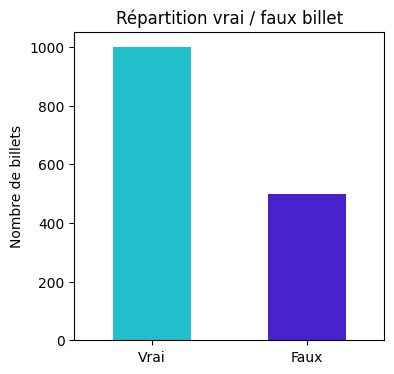

In [14]:
#Vérification du jeu de billets

effectifs = billets["is_genuine"].value_counts()
print(f"Vrais billets : {effectifs[True]} ({effectifs[True] / len(billets):.1%})")
print(f"Faux billets  : {effectifs[False]} ({effectifs[False] / len(billets):.1%})")

fig, ax = plt.subplots(figsize=(4, 4))
effectifs.rename({True: "Vrai", False: "Faux"}).plot(kind="bar", color=["#22becc", "#4a22cc"], ax=ax)
ax.set_title("Répartition vrai / faux billet")
ax.set_xlabel("")
ax.set_ylabel("Nombre de billets")
plt.xticks(rotation=0)
plt.show()

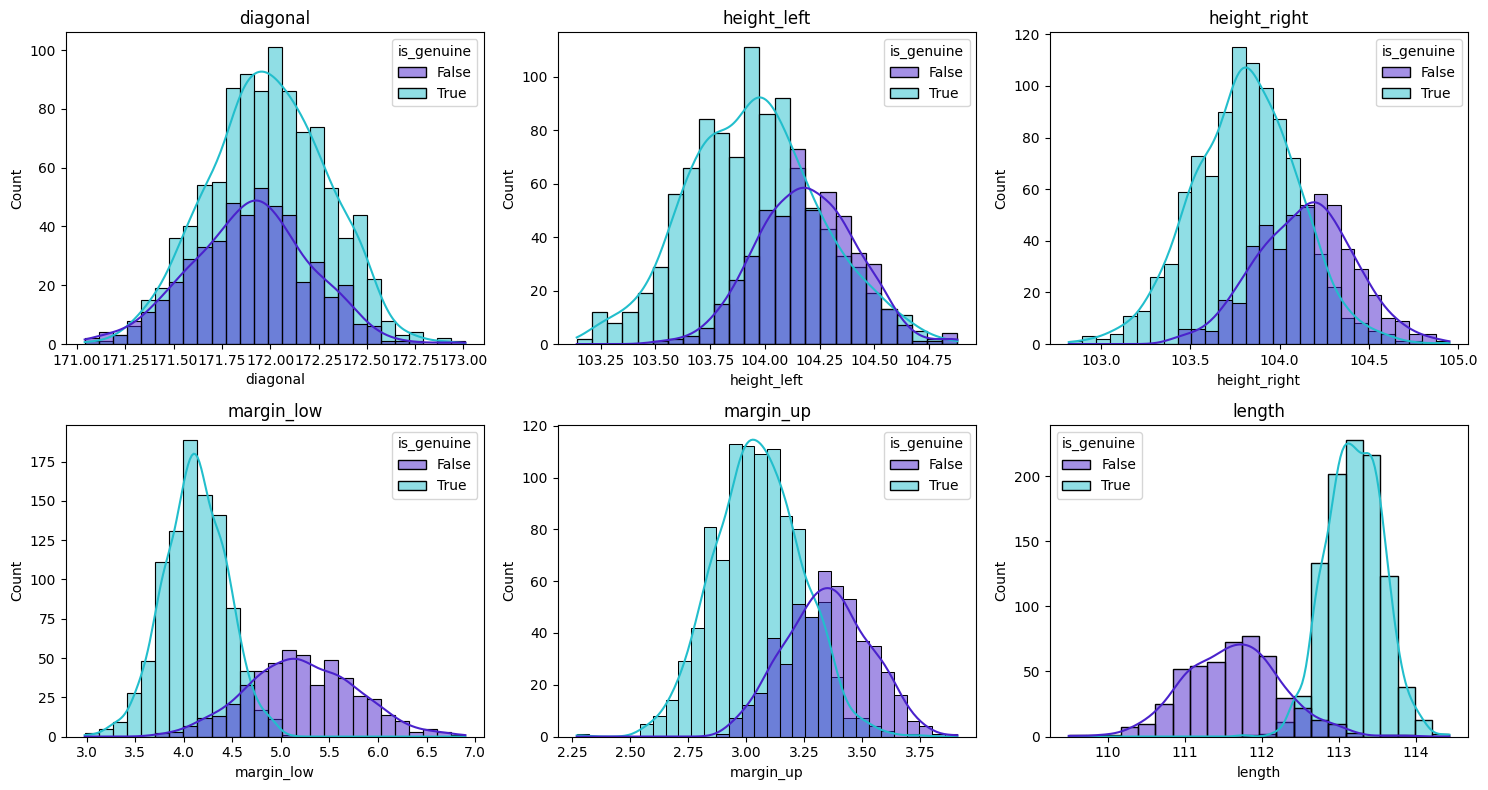

In [15]:
variables = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, variable in zip(axes.flat, variables):
    sns.histplot(data=billets, x=variable, hue="is_genuine", kde=True, palette=["#4a22cc", "#22becc"], ax=ax)
    ax.set_title(variable)
plt.tight_layout()
plt.show()

Les histogrammes affichent, pour chacune des 6 mesures géométriques, comment les valeurs se répartissent selon que le billet est vrai ou faux : quand les deux courbes sont bien séparées.

Cette mesure aide déjà beaucoup à elle seule à distinguer un vrai d'un faux billet.

<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Traitement des valeurs manquantes: margin_low </h3>
</div>

In [16]:
print(f"Valeurs manquantes sur margin_low : {billets['margin_low'].isna().sum()} "
      f"({billets['margin_low'].isna().mean():.1%})")

billets[variables].corr()["margin_low"].sort_values(ascending=False)

Valeurs manquantes sur margin_low : 37 (2.5%)


margin_low      1.000000
margin_up       0.431606
height_right    0.391085
height_left     0.302643
diagonal       -0.111534
length         -0.666753
Name: margin_low, dtype: float64

### Objectif: vérifier si la régression linéaire est vraiment meilleure que la médiane pour deviner margin_low.

Deux méthodes:

DummyRegressor(strategy="median") : un modèle volontairement naïf qui ignore toutes les variables et prédit toujours la médiane de margin_low observée.

LinearRegression() : La validation croisée (cv=5).

Au lieu d'entraîner et de tester une fois, on découpe les 1463 lignes en 5 groupes égaux. Le modèle s'entraîne 5 fois : à chaque tour, il apprend sur 4 groupes et prédit sur le 5ᵉ (qu'il n'a jamais vu). 

Résultat : 5 scores d'erreur dont on prend la moyenne. C'est plus fiable qu'un seul découpage train/test qui peut donner un résultat chanceux ou malchanceux selon le hasard du split.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

features_imputation = [v for v in variables if v != "margin_low"]
connu = billets["margin_low"].notna()

X_connu = billets.loc[connu, features_imputation]
y_connu = billets.loc[connu, "margin_low"]

# Comparaison par validation croisée (5 folds) sur les 1463 billets où margin_low est connu.
comparaison_imputation = {}
for nom, modele in {
    "Médiane": DummyRegressor(strategy="median"),
    "Régression linéaire": LinearRegression(),
}.items():
    mae = -cross_val_score(modele, X_connu, y_connu, cv=5, scoring="neg_mean_absolute_error").mean()
    rmse = (-cross_val_score(modele, X_connu, y_connu, cv=5, scoring="neg_mean_squared_error").mean()) ** 0.5
    comparaison_imputation[nom] = {"MAE": mae, "RMSE": rmse}

pd.DataFrame(comparaison_imputation).T.round(3)

,MAE,RMSE
Médiane,0.571,0.752
Régression linéaire,0.383,0.495


MAE (Mean Absolute Error) : moyenne des écarts absolus entre valeur prédite et vraie valeur. Simple à interpréter : "en moyenne, on se trompe de X mm".
RMSE (Root Mean Squared Error) : les écarts sont élevés au carré avant d'être moyennés, puis on prend la racine carrée. Ça pénalise davantage les grosses erreurs qu'une petite série de petits écarts — utile pour savoir si le modèle fait quelques grosses erreurs isolées, plutôt que d'être uniformément un peu à côté.

La régression linéaire réduit l'erreur d'environ un tiers par rapport à la médiane
(MAE : 0,38 mm contre 0,57 mm ; RMSE : 0,50 mm contre 0,75 mm), en s'appuyant sur la corrélation
de `margin_low` avec les autres mesures géométriques plutôt que sur une seule valeur constante
pour tout le jeu de données. C'est ce résultat, mesuré par validation croisée sur les billets
où `margin_low` est connu, qui justifie le choix de la régression pour imputer les 37 valeurs
manquantes.

In [18]:
modele_imputation = LinearRegression()
modele_imputation.fit(billets.loc[connu, features_imputation], billets.loc[connu, "margin_low"])

manquant = ~connu
billets.loc[manquant, "margin_low"] = modele_imputation.predict(billets.loc[manquant, features_imputation])

print(f"Valeurs manquantes restantes sur margin_low : {billets['margin_low'].isna().sum()}")

Valeurs manquantes restantes sur margin_low : 0


**Choix : imputation par régression linéaire**, `margin_low` étant prédit à partir des 5 autres
variables géométriques (`diagonal`, `height_left`, `height_right`, `margin_up`, `length`),
plutôt qu'une suppression des lignes ou une médiane.

<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Préparation des données </h3>
</div>

In [19]:
X = billets[variables]
y = billets["is_genuine"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} billets, Test : {X_test.shape[0]} billets")

Train : 1200 billets, Test : 300 billets


On sépare les billets en deux groupes : 80 % pour entraîner les modèles (« train »), 20 % pour les tester sur des billets jamais vus (« test »). C'est indispensable pour vérifier qu'un modèle généralise bien et ne se contente pas d'avoir appris par cœur les billets d'entraînement. On applique aussi une standardisation, qui met toutes les mesures à la même échelle : nécessaire pour la régression logistique, le KNN et le k-means, sensibles aux différences d'unités entre variables. Le random forest n'en a pas besoin, car il compare les valeurs entre elles sans notion de distance.

<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Entraînement des modèles 🤖</h3>
</div>

Quatre méthodes sont entraînées et comparées, chacune avec sa propre logique :

- la régression logistique calcule une probabilité qu'un billet soit vrai ou faux, à partir d'une combinaison des 6 mesures,
- le k-means est normalement une méthode qui regroupe des données en paquets similaires sans connaître les étiquettes vrai/faux,
(Ici, on le détourne pour la prédiction en associant chacun des 2 groupes trouvés à la catégorie majoritaire des billets d'entraînement qu'il contient)
- le KNN classe un billet en regardant les 5 billets qui lui ressemblent le plus dans les données d'entraînement et prend la catégorie majoritaire parmi eux,
- le random forest construit de nombreux arbres de décision indépendants et fait voter leurs prédictions pour un résultat plus robuste qu'un seul arbre.

In [ ]:
#predictions = {} crée un dictionnaire vide, une structure qui associe des clés à des valeurs (ici, plus loin dans le code : predictions["Régression logistique"] = ..., predictions["KNN"] = ..., etc.)
predictions = {}

### Régression logistique

Calcule, à partir d'une combinaison pondérée des 6 mesures géométriques, une probabilité que le billet soit vrai ou faux (entre 0 et 1). Si cette probabilité dépasse 0,5, le billet est classé dans une catégorie, sinon dans l'autre. C'est un modèle simple et rapide dont on peut interpréter les résultats : chaque variable a un poids, qui indique son influence sur la décision finale.

In [ ]:

# 1. Régression logistique
log_reg = LogisticRegression(random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
predictions["Régression logistique"] = log_reg.predict(X_test_scaled)

### K-means

Méthode de clustering, qui regroupe des points qui se ressemblent, sans connaître à l'avance leur catégorie. 
On forme 2 groupes à partir des 6 mesures, sans donner l'information vrai/faux. On regarde ensuite, pour chaque groupe formé, quelle catégorie de billets y est majoritaire (vrai ou faux) et on étiquete les nouveaux billets selon le groupe auquel ils sont le plus proches.

In [21]:
# 2. K-means (2 centroïdes, chacun rattaché à la classe majoritaire des billets du train qui lui sont associés)
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
clusters_train = kmeans.fit_predict(X_train_scaled)

cluster_to_label = (
    pd.Series(y_train.values).groupby(clusters_train).agg(lambda s: s.mode()[0])
)

clusters_test = kmeans.predict(X_test_scaled)
predictions["K-means"] = pd.Series(clusters_test).map(cluster_to_label).values

### KNN (K-Nearest Neighbors, "k plus proches voisins")

Pour un nouveau billet, on regarde les 5 billets (le "K" du nom) qui lui ressemblent le plus dans les données déjà connues, en comparant leurs mesures géométriques. On prend ensuite la catégorie majoritaire parmi ces 5 voisins (par exemple, si 4 sont vrais et 1 est faux, le nouveau billet est classé vrai). C'est une méthode qui ne "calcule" rien à l'avance : à chaque nouvelle prédiction, elle recompare le billet à tous les billets connus.

In [22]:
# 3. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
predictions["KNN"] = knn.predict(X_test_scaled)

### Random Forest

Un random forest construit un grand nombre d'arbres de décision, chacun entraîné sur une portion légèrement différente des données. Un arbre de décision, seul, pose une série de questions successives sur les variables pour arriver à une classification. Un seul arbre peut se tromper facilement ou trop coller à ses données d'entraînement. Mais en faisant voter plusieurs centaines d'arbres différents et en gardant la réponse majoritaire, le résultat devient beaucoup plus stable et fiable. C'est le principe du "vote collectif" : les erreurs individuelles de chaque arbre ont tendance à s'annuler.

In [23]:
# 4. Random Forest (pas besoin de standardisation)
random_forest = RandomForestClassifier(random_state=RANDOM_STATE)
random_forest.fit(X_train, y_train)
predictions["Random Forest"] = random_forest.predict(X_test)

<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Évaluation comparée des modèles </h3>
</div>

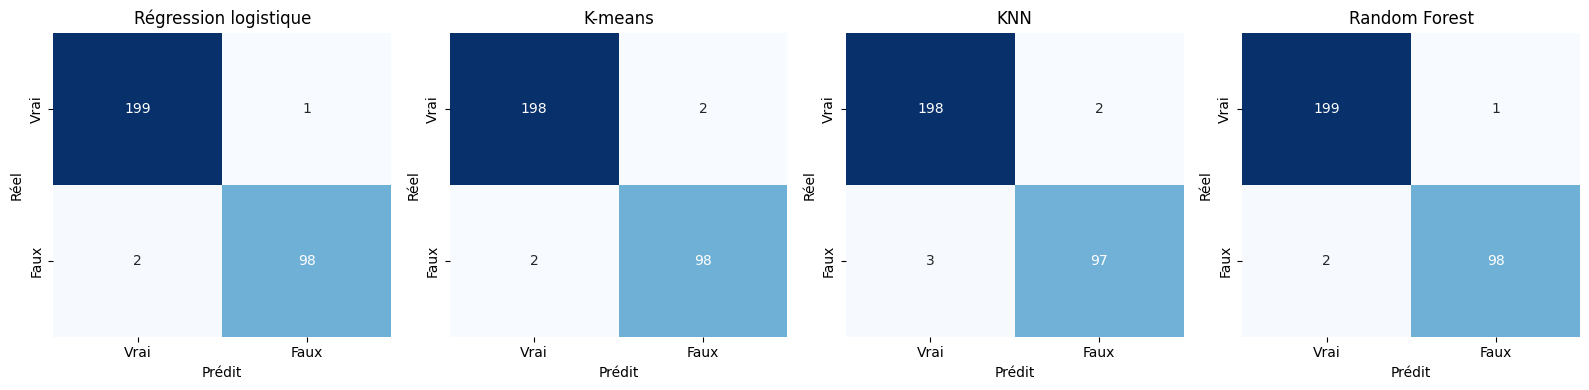

In [24]:
fig, axes = plt.subplots(1, len(predictions), figsize=(4 * len(predictions), 4))
for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    matrice = confusion_matrix(y_test, y_pred, labels=[True, False])
    sns.heatmap(
        matrice, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Vrai", "Faux"], yticklabels=["Vrai", "Faux"], ax=ax,
    )
    ax.set_title(nom_modele)
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()
plt.show()

In [25]:
for nom_modele, y_pred in predictions.items():
    print(f"--- {nom_modele} ---")
    print(classification_report(y_test, y_pred, target_names=["Faux", "Vrai"], labels=[False, True]))

--- Régression logistique ---
              precision    recall  f1-score   support

        Faux       0.99      0.98      0.98       100
        Vrai       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

--- K-means ---
              precision    recall  f1-score   support

        Faux       0.98      0.98      0.98       100
        Vrai       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300

--- KNN ---
              precision    recall  f1-score   support

        Faux       0.98      0.97      0.97       100
        Vrai       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg    

In [26]:
from sklearn.metrics import precision_score, f1_score, accuracy_score

# Tableau de synthèse : le rappel sur la classe "faux billet" est le critère de sélection
synthese = pd.DataFrame({
    nom_modele: {
        "Rappel faux": recall_score(y_test, y_pred, pos_label=False),
        "Précision faux": precision_score(y_test, y_pred, pos_label=False),
        "F1 faux": f1_score(y_test, y_pred, pos_label=False),
        "Rappel vrai": recall_score(y_test, y_pred, pos_label=True),
        "Accuracy": accuracy_score(y_test, y_pred),
    }
    for nom_modele, y_pred in predictions.items()
}).T.round(3)

synthese.sort_values("Rappel faux", ascending=False)

,Rappel faux,Précision faux,F1 faux,Rappel vrai,Accuracy
Régression logistique,0.98,0.99,0.985,0.995,0.990
K-means,0.98,0.98,0.980,0.990,0.987
Random Forest,0.98,0.99,0.985,0.995,0.990
KNN,0.97,0.98,0.975,0.990,0.983


**Conclusions**

Les 4 modèles obtiennent tous de très bons résultats, mais avec des nuances. 

Le critère le plus important est le « rappel faux »: la part des vrais "faux billets" effectivement détectés par le modèle, car un faux billet qui passe pour un vrai est l'erreur la plus coûteuse pour l'ONCFM.

Sur ce critère, la régression logistique, le random forest et le k-means atteignent tous 0,98 : sur 100 faux billets, 98 sont correctement repérés. Le KNN est légèrement en retrait à 0,97.

Pour départager les modèles à égalité sur le rappel, on regarde les autres colonnes. La régression logistique et le random forest se détachent alors clairement : ils obtiennent les meilleurs scores sur toutes les autres métriques et sont même parfaitement identiques entre eux sur ce tableau. Le k-means, bien que proche, reste légèrement en dessous sur la précision (0,98 contre 0,99) et l'accuracy (0,987 contre 0,990).

Par conséquent, régression logistique et random forest se détachent comme les deux meilleurs candidats (à égalité stricte sur ce tableau).
Le k-means suit de près et le KNN ferme la marche.

<div style="border: 3px solid #4a22cc;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #22becc; ">Sélection du modèle final 🏆</h3>
</div>

In [27]:
meilleur_modele = synthese["Rappel faux"].idxmax()
print(f"Modèle retenu : {meilleur_modele} (rappel faux billet = {synthese.loc[meilleur_modele, 'Rappel faux']})")
synthese.loc[[meilleur_modele]]

Modèle retenu : Régression logistique (rappel faux billet = 0.98)


,Rappel faux,Précision faux,F1 faux,Rappel vrai,Accuracy
Régression logistique,0.98,0.99,0.985,0.995,0.99


**Le modèle final est sélectionné automatiquement sur le rappel de la classe "faux billet"**
Conformément au critère prioritaire de l'ONCFM : un faux billet classé comme vrai (faux négatif) est l'erreur la plus coûteuse, bien plus qu'un vrai billet faussement rejeté. L'accuracy globale n'intervient pas dans ce choix: un modèle avec une accuracy légèrement inférieure mais un meilleur rappel sur les faux billets lui est préféré.

**Résultat obtenu : régression logistique**, avec un rappel de 0,98 sur la classe "faux billet" (2 faux billets sur 100 mal classés comme vrais dans le jeu de test), une précision de 0,99 et une accuracy globale de 0,99.

La régression logistique est à égalité stricte avec la Random Forest sur les 5 métriques du tableau de synthèse. 

Le choix automatique (`idxmax`) retient la régression logistique, premier modèle atteignant le score maximal:
un choix défendable ici puisqu'à métriques strictement égales, c'est le modèle le plus simple et le plus interprétable des deux ex æquo, ce qui facilite l'explication des décisions à l'ONCFM.

In [28]:
import joblib

artefacts = {
    "modele_imputation": modele_imputation,
    "features_imputation": features_imputation,
    "variables": variables,
    "modele": log_reg,
    "scaler": scaler,
}

joblib.dump(artefacts, "model_final.pkl")
print("Modèle sérialisé dans model_final.pkl (Régression logistique)")

Modèle sérialisé dans model_final.pkl (Régression logistique)
